In [47]:
import rebound
import reboundx
import astropy.constants as constants
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from multiprocess import Pool
import celmech
import scipy.fftpack as fftpack

import seaborn as sns
import scipy.stats as stats


import os
import glob
from pathlib import Path

import warnings
from joblib import Parallel, delayed
from celmech.miscellaneous import frequency_modified_fourier_transform as fmftc

In [48]:
#helper functions
def findAllIn(data_dir, file_matching, contain_dir=False, save_ls=True, save_name=None):
    if data_dir[-1] != '/':
        data_dir = data_dir + '/'
    if save_name == None:
        save_name = 'all_' + file_matching + '.txt'
    list_files = glob.glob(data_dir + file_matching)
    if not contain_dir:
        list_files[:] = (os.path.basename(i) for i in list_files)
    if save_ls:
        with open(data_dir + save_name, "w") as output:
            for i in list_files:
                output.write(str(i) + '\n')
    return list_files

In [49]:
def fft(e, interval):
    amplitudes = fftpack.rfft(e[2::])
    frequencies = fftpack.rfftfreq(n=len(e[2::]), d=interval)
    return frequencies, amplitudes

In [50]:
def analysis(name):
    sa = rebound.Simulationarchive(name) 
    tmax = sa.tmax
    print("t is:",tmax/1e6, "myr")
    Nsnaps = len(sa)
    interval = int(abs((tmax-sa.tmin)/Nsnaps))
    
    print("Snapshot length is:",interval/1e3, "ky")
    
    Nout = Nsnaps
    
    obl = np.zeros(Nout)
    esinw = np.zeros(Nout)
    e = np.zeros(Nout)
    p = np.zeros(Nout)
    pom = np.zeros(Nout)
    incs = np.zeros(Nout)
    els = np.zeros(Nout)
    times = np.zeros(Nout)
    
    n = 8
    a = np.zeros((Nout,n))
    z = np.zeros((Nout, n), dtype=complex)
    ζ = np.zeros((Nout, n), dtype=complex)
    
    for i, sim in enumerate(sa):
        sim.move_to_com
        sim.integrator_synchronize()
        qps = sim.particles
        earth = qps['earth']
        time = sim.t
        times[i]=time
    
        sim.integrator_synchronize()
        orbits = sim.orbits()
        
        for j in range(n):
            a[i,j] = orbits[j].a
            z[i,j] = orbits[j].e * np.exp(1j*orbits[j].pomega)
            ζ[i,j] = np.sin(orbits[j].inc/2.) * np.exp(1j*orbits[j].Omega)
    
        # Omega = np.array(qps['earth'].params['Omega'])
        # h = np.array(qps['earth'].hvec)
        # obl[i] = np.arccos(np.dot(Omega, h)/np.linalg.norm(Omega)/np.linalg.norm(h))*180/np.pi
        esinw[i] = qps['earth'].e*np.sin(qps['earth'].pomega)
        e[i] = qps['earth'].e
        p[i] = (1 - (qps['earth'].e)**2) / (1 + (qps['earth'].e * np.cos(qps['earth'].f)))
        pom[i] = np.sin(qps['earth'].pomega)
        incs[i] = qps['earth'].inc
        els[i] = qps['earth'].l
    
    t=times
    # sins = celmech.miscellaneous.frequency_modified_fourier_transform(t[2::],e[2::],Nfreq=4, method_flag=2, max_freq=20/u.rad.to(u.arcsec), min_freq=2/u.rad.to(u.arcsec))
    sins = celmech.miscellaneous.frequency_modified_fourier_transform(t[2::],e[2::],Nfreq=60, method_flag=2)
    freqs = np.zeros(len(sins))
    amps = np.zeros(len(sins))

    
    
    frequencies, amplitudes = fft(e,interval)

        
    return freqs[2::],amps[2::], sins, frequencies, amplitudes

In [51]:
PATH = '/home/ahekster/reboundx/ipython_examples/samples'

ls = findAllIn(PATH, 'R_*_*3260.bin', True, False)

ls;

In [52]:
%%capture

result = []
for index, name in enumerate(ls):
    result.append(analysis(name))

In [53]:
%%capture

for index, name in enumerate(ls):
    sins = result[index][2]

    print('Earth:')
    print(f'   {"Frequency":10s} {"Amp (x10^6)":10s}')
    for index, key in enumerate(sins):
        if index == 0 or index >=7:
            continue
        print(f'{(2*np.pi/abs(key))*1e-3 :10.2f} Kyr {np.abs(sins[key])*1e6:12,.0f}')

403.87 Kyr: 5,387

In [54]:
# plt.vlines(result[0][0],result[0][1],'.','purple')
# plt.vlines(result[1][0],result[1][1],'.','red')
# plt.show()

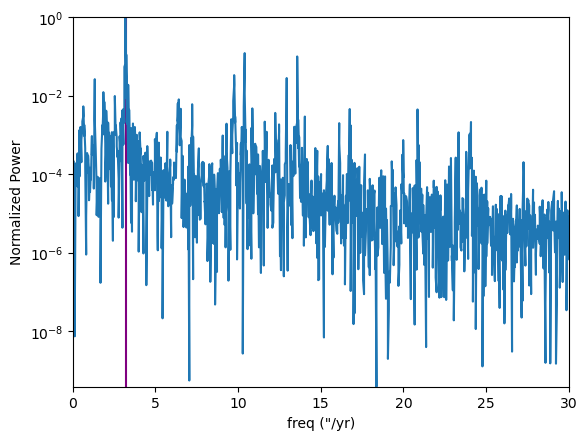

In [55]:
fig, ax = plt.subplots()
i=62
ax.vlines(3.24,np.max((result[i][4][1::])**2/np.max((result[i][4][1::])**2)),'--','purple')

ax.plot((result[i][3][1::]) * u.rad.to(u.arcsec)*(2*np.pi),(result[i][4][1::])**2/np.max((result[i][4][1::])**2))


ax.set_yscale('log')
ax.set_xlabel('freq ("/yr)')
ax.set_ylabel('Normalized Power')
ax.set_ylim(np.min((result[i][4][1::])**2/np.max((result[i][4][1::])**2)),1)
ax.set_xlim(0,30)
ax.set_ylim(None, 1e0)
plt.show()

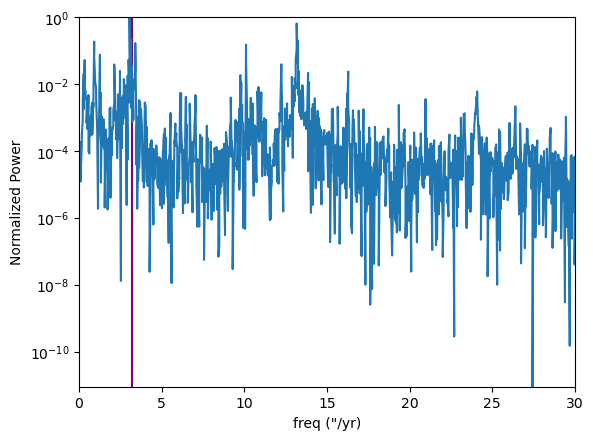

In [56]:
fig, ax = plt.subplots()
i=56
ax.vlines(3.24,np.max((result[i][4][1::])**2/np.max((result[i][4][1::])**2)),'--','purple')

ax.plot((result[i][3][1::]) * u.rad.to(u.arcsec)*(2*np.pi),(result[i][4][1::])**2/np.max((result[i][4][1::])**2))


ax.set_yscale('log')
ax.set_xlabel('freq ("/yr)')
ax.set_ylabel('Normalized Power')
ax.set_ylim(np.min((result[i][4][1::])**2/np.max((result[i][4][1::])**2)),1)
ax.set_xlim(0,30)
ax.set_ylim(None, 1e0)
plt.show()

all 40%, if this happens 10% of the time, we have 2x20 Myr periods

0,96**64 ~ 7

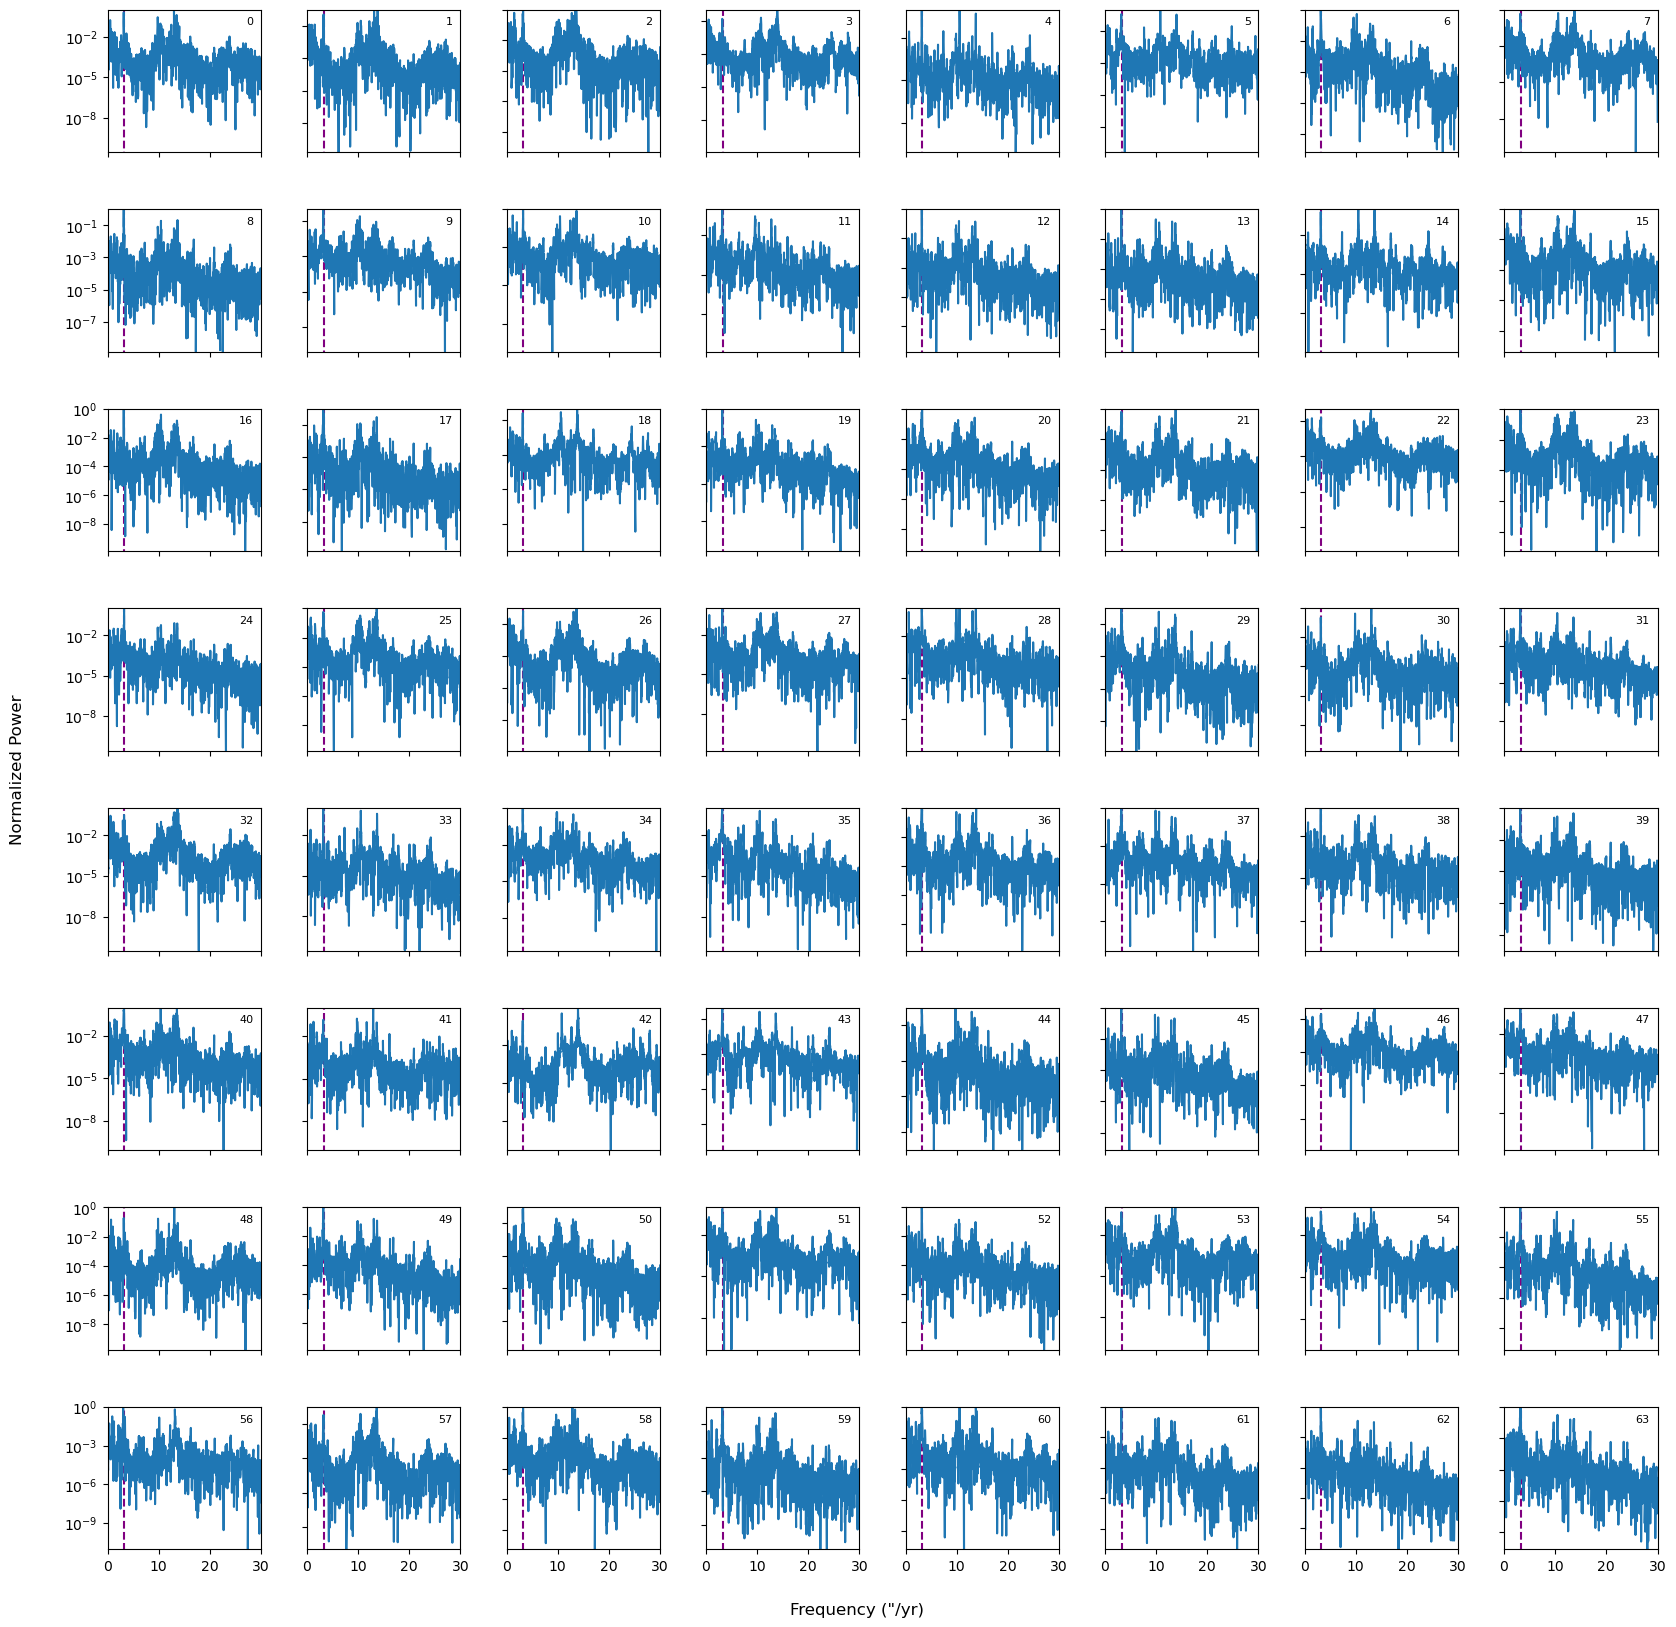

<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

In [57]:
fig, axs = plt.subplots(8, 8, figsize=(20, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, ax in enumerate(axs.flat):
    ax.vlines(3.24, 0, 1, colors='purple', linestyles='--')
    
    normalized_power = (result[i][4][1::])**2 / np.max((result[i][4][1::])**2)
    x_data = (result[i][3][1::]) * u.rad.to(u.arcsec) * (2*np.pi)
    ax.plot(x_data, normalized_power)
    
    ax.set_yscale('log')
    ax.set_xlim(0, 30)
    ax.set_ylim(np.min(normalized_power), 1)
    
    if i < 56:  
        ax.set_xticklabels([])
    if i % 8 != 0: 
        ax.set_yticklabels([])
    
    ax.text(0.95, 0.95, str(i), transform=ax.transAxes, 
            ha='right', va='top', fontsize=8)

fig.text(0.5, 0.08, 'Frequency ("/yr)', ha='center', va='center', fontsize=12)
fig.text(0.08, 0.5, 'Normalized Power', ha='center', va='center', 
         rotation='vertical', fontsize=12)

plt.show()
plt.savefig

In [58]:
target_period_kyr = 405.0  
tol_kyr = 30.0

lec_amplitudes = []  
lec_periods = []

for sim_idx, name in enumerate(ls):
    sinsx = result[sim_idx][2] 
    found = False
    
    print(f"Simulation {sim_idx}:")
    print(f'   {"Period (kyr)":15s} {"Amp (x10^6)":15s}')
    
    for key in sinsx.keys():
        period = (2 * np.pi / abs(key)) * 1e-3  
        
        if abs(period - target_period_kyr) <= tol_kyr:
            lec_periods.append(period)
            amp_val = np.abs(sinsx[key]) * 1e6 
            print(f"{period:15.2f} {amp_val:15,.0f}")
            lec_amplitudes.append(amp_val)
            found = True
            break
    
    if not found:
        lec_amplitudes.append(np.nan)
        print("  No LEC frequency found within the target range.")
    print("\n")

lec_periods = np.array(lec_periods)
lec_amplitudes = np.array(lec_amplitudes)
lec_amplitudes = (5387)/lec_amplitudes

mean_amp = np.nanmean(lec_amplitudes)
std_amp = np.nanstd(lec_amplitudes)

Simulation 0:
   Period (kyr)    Amp (x10^6)    
         408.25           3,819


Simulation 1:
   Period (kyr)    Amp (x10^6)    
         404.14           2,710


Simulation 2:
   Period (kyr)    Amp (x10^6)    
         406.47           3,321


Simulation 3:
   Period (kyr)    Amp (x10^6)    
         409.87           2,279


Simulation 4:
   Period (kyr)    Amp (x10^6)    
         408.38           6,282


Simulation 5:
   Period (kyr)    Amp (x10^6)    
         410.60           5,220


Simulation 6:
   Period (kyr)    Amp (x10^6)    
         407.20           6,814


Simulation 7:
   Period (kyr)    Amp (x10^6)    
         407.08           2,826


Simulation 8:
   Period (kyr)    Amp (x10^6)    
         407.74           5,861


Simulation 9:
   Period (kyr)    Amp (x10^6)    
         408.07           6,976


Simulation 10:
   Period (kyr)    Amp (x10^6)    
         402.78           4,206


Simulation 11:
   Period (kyr)    Amp (x10^6)    
         409.96           6,921


Si

In [59]:
print("Ensemble LEC amplitude statistics:")
print("Mean LEC amplitude:",mean_amp)
print("Std  LEC amplitude:", std_amp)

Ensemble LEC amplitude statistics:
Mean LEC amplitude: 1.195222398233369
Std  LEC amplitude: 0.500813570914196


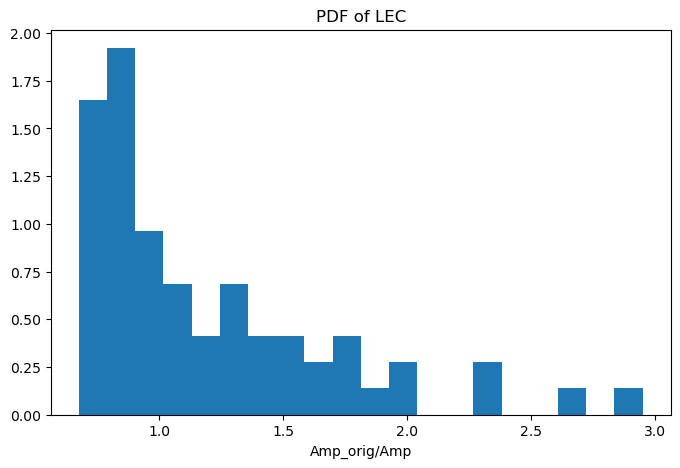

In [60]:
plt.figure(figsize=(8, 5))
plt.hist(lec_amplitudes[~np.isnan(lec_amplitudes)], bins=20, cumulative=0,density=1)
plt.xlabel("Amp_orig/Amp")
# plt.ylabel("Number of Simulations")
plt.title("PDF of LEC")
# plt.xlim(1,None)
plt.show()


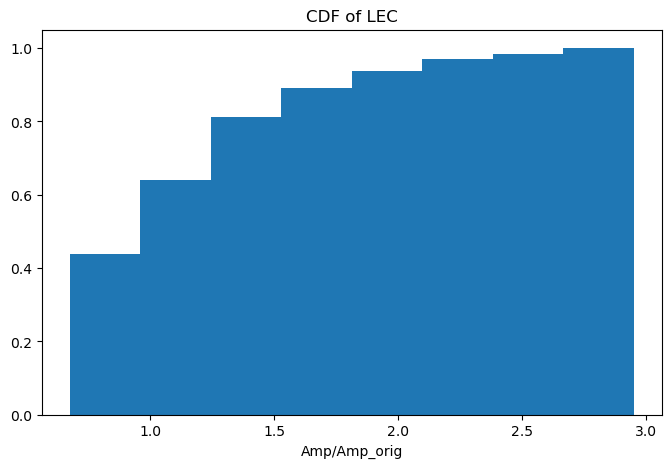

In [61]:
plt.figure(figsize=(8, 5))
plt.hist(lec_amplitudes[~np.isnan(lec_amplitudes)], bins='auto', cumulative=1,density=1)
plt.xlabel("Amp/Amp_orig")
# plt.ylabel("Number of Simulations")
plt.title("CDF of LEC")
# plt.xlim(1,None)
plt.show()


original 403.87 Kyr,

amp 5,387

In [62]:
if lec_periods.size > 0:
    weighted_mean = np.average(lec_periods, weights=lec_amplitudes)
    weighted_std = np.sqrt(np.average((lec_periods - weighted_mean)**2, weights=lec_amplitudes))
    
    print("  Weighted mean period: {:.2f} kyr".format(weighted_mean))
    print("  Weighted std (width) : {:.2f} kyr".format(weighted_std))

  Weighted mean period: 407.10 kyr
  Weighted std (width) : 3.39 kyr


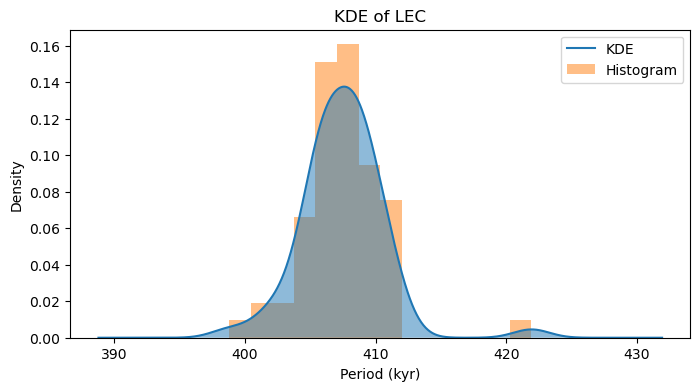

In [63]:
kde = stats.gaussian_kde(lec_periods, bw_method='scott')

x_range = np.linspace(lec_periods.min()-10, lec_periods.max()+10, 1000)

density_values = kde(x_range)

plt.figure(figsize=(8, 4))
# plt.vlines(403.87, 0,0.3, colors='purple', linestyles='--', label ='Original')
# plt.vlines(407.42, 0,0.3, colors='black', linestyles='--', label='3 Gyr')
# plt.vlines(np.mean(lec_periods), 0,0.3,colors='black', linestyles='--', label='1.5 Gyr')

plt.plot(x_range, density_values, label='KDE')
plt.hist(lec_periods, bins='auto', density=1, alpha=0.5, label='Histogram')

plt.fill_between(x_range, density_values, alpha=0.5)
plt.xlabel('Period (kyr)')
plt.ylabel('Density')
plt.title('KDE of LEC')
plt.legend()
plt.show()

In [64]:
#analysis with all possible frequencies

lec_amplitudes_full = []  
lec_periods_full = []

for sim_idx, name in enumerate(ls):
    sinsx = result[sim_idx][2] 
    found = False
    
    for key in sinsx.keys():
        period = (2 * np.pi / abs(key)) * 1e-3  
        
        if abs(period - target_period_kyr) <= tol_kyr:
            lec_periods_full.append(period)
            amp_val = np.abs(sinsx[key]) * 1e6 
            lec_amplitudes_full.append(amp_val)
            found = True
            # break 
    
    if not found:
        lec_amplitudes_full.append(np.nan)

lec_periods_full = np.array(lec_periods_full)
lec_amplitudes_full = np.array(lec_amplitudes_full)
lec_amplitudes_full = (5387)/lec_amplitudes_full

In [65]:
mean_amp = np.nanmean(lec_amplitudes_full)
std_amp = np.nanstd(lec_amplitudes_full)

if lec_periods.size > 0:
    weighted_mean = np.average(lec_periods_full, weights=lec_amplitudes_full)
    weighted_std = np.sqrt(np.average((lec_periods_full - weighted_mean)**2, weights=lec_amplitudes_full))
    
    print("  Weighted mean period: {:.2f} kyr".format(weighted_mean))
    print("  Weighted std (width) : {:.2f} kyr".format(weighted_std))

  Weighted mean period: 410.42 kyr
  Weighted std (width) : 15.76 kyr


In [66]:
# np.savez('data_3260.npz',
#          lec_amplitudes_full=lec_amplitudes_full,
#          lec_periods_full=lec_periods_full,
#          lec_amplitudes=lec_amplitudes,
#          lec_periods=lec_periods)

In [67]:
data_3260 = np.load('data_3260.npz')
data_1190 = np.load('data_1190.npz')

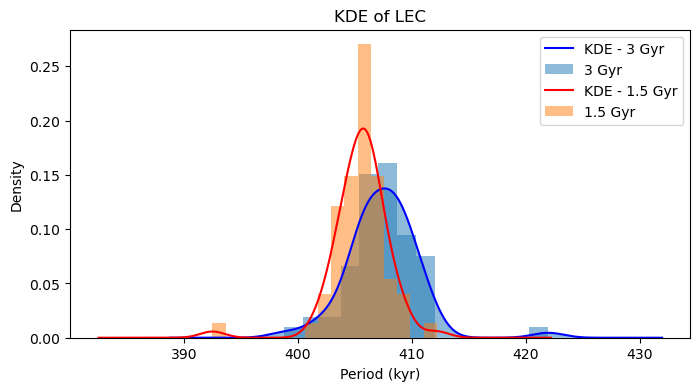

In [68]:
lec_periods_3260 = data_3260['lec_periods']
lec_periods_1190 = data_1190['lec_periods']

plt.figure(figsize=(8, 4))


kde = stats.gaussian_kde(lec_periods_3260, bw_method='scott')
x_range = np.linspace(lec_periods_3260.min()-10, lec_periods_3260.max()+10, 1000)
density_values = kde(x_range)
plt.plot(x_range, density_values,'blue', label='KDE - 3 Gyr')
plt.hist(lec_periods_3260, bins='auto', density=1, alpha=0.5, label='3 Gyr')
plt.fill_between(x_range, density_values, alpha=0.5)

kde = stats.gaussian_kde(lec_periods_1190, bw_method='scott')
x_range = np.linspace(lec_periods_1190.min()-10, lec_periods_1190.max()+10, 1000)
density_values = kde(x_range)
plt.plot(x_range, density_values, 'red',label='KDE - 1.5 Gyr')
plt.hist(lec_periods_1190, bins='auto', density=1, alpha=0.5, label='1.5 Gyr')

plt.xlabel('Period (kyr)')
plt.ylabel('Density')
plt.title('KDE of LEC')
plt.legend()
plt.show()

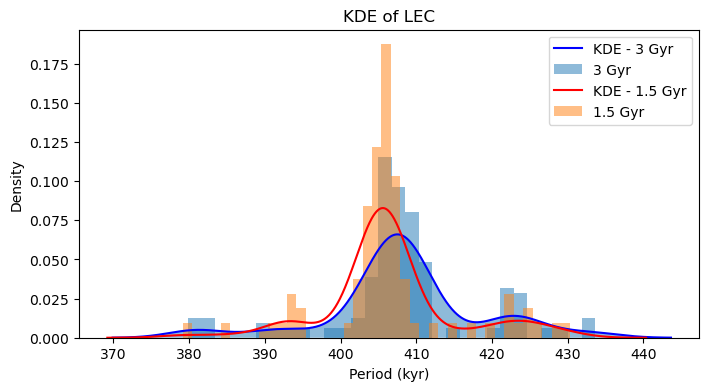

In [69]:
lec_periods_3260 = data_3260['lec_periods_full']
lec_periods_1190 = data_1190['lec_periods_full']

plt.figure(figsize=(8, 4))


kde = stats.gaussian_kde(lec_periods_3260, bw_method='scott')
x_range = np.linspace(lec_periods_3260.min()-10, lec_periods_3260.max()+10, 1000)
density_values = kde(x_range)
plt.plot(x_range, density_values,'blue', label='KDE - 3 Gyr')
plt.hist(lec_periods_3260, bins='auto', density=1, alpha=0.5, label='3 Gyr')
plt.fill_between(x_range, density_values, alpha=0.5)

kde = stats.gaussian_kde(lec_periods_1190, bw_method='scott')
x_range = np.linspace(lec_periods_1190.min()-10, lec_periods_1190.max()+10, 1000)
density_values = kde(x_range)
plt.plot(x_range, density_values, 'red',label='KDE - 1.5 Gyr')
plt.hist(lec_periods_1190, bins='auto', density=1, alpha=0.5, label='1.5 Gyr')

plt.xlabel('Period (kyr)')
plt.ylabel('Density')
plt.title('KDE of LEC')
plt.legend()
plt.show()